In [6]:
# Cell 1: Force update repo
!git reset --hard
!git pull origin main

HEAD is now at 479236e Fix Transformer constructor parameter naming mismatch and clean scripts/train.py
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 9 (delta 6), reused 9 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 3.35 KiB | 342.00 KiB/s, done.
From https://github.com/BELYAGOUBIABDELILAH/llm-from-scratch
 * branch            main       -> FETCH_HEAD
   479236e..5fbc424  main       -> origin/main
Updating 479236e..5fbc424
Fast-forward
 01_benchmarks.ipynb          | 249 +++++++++++++++++++++----------------------
 02_arabic_lm.ipynb           | 146 ++++++++++++-------------
 data_loader/arabic_loader.py |  30 +++---
 src/models/transformer.py    |  13 +--
 4 files changed, 212 insertions(+), 226 deletions(-)


# LLM from Scratch — Benchmark Comparison
## 13M vs 30M vs 60M Parameters

This notebook trains three Transformer models from scratch and compares:
- Training loss curves
- Perplexity scores
- Training time
- GPU memory usage
- Text generation quality

Architecture: [Attention Is All You Need](https://arxiv.org/abs/1706.03762) (Vaswani et al., 2017)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BELYAGOUBIABDELILAH/llm-from-scratch/blob/main/01_benchmarks.ipynb)

In [7]:
# ── Install dependencies ──────────────────────────────────────
!pip install torch datasets transformers tqdm matplotlib -q

# ── Clone repo (safe: skip if already cloned) ─────────────────
import os
if not os.path.exists('llm-from-scratch'):
    !git clone https://github.com/BELYAGOUBIABDELILAH/llm-from-scratch
%cd llm-from-scratch
!git pull origin main

# ── Mount Google Drive ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/llm_project/benchmarks'
os.makedirs(f'{DRIVE_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/images',      exist_ok=True)
print(f'Drive mounted — outputs will be saved to: {DRIVE_DIR}')

# ── Imports ───────────────────────────────────────────────────
import torch
import time
import json
import shutil
import matplotlib.pyplot as plt
from tqdm import tqdm
from datasets import load_dataset
from transformers import GPT2Tokenizer
from src.models.transformer import Transformer
from config.config import MODEL_CONFIGS, TRAIN_CONFIG

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

/content/llm-from-scratch/llm-from-scratch
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 18 (delta 11), reused 17 (delta 10), pack-reused 0 (from 0)
Unpacking objects: 100% (18/18), 6.14 KiB | 392.00 KiB/s, done.
From https://github.com/BELYAGOUBIABDELILAH/llm-from-scratch
 * branch            main       -> FETCH_HEAD
   c37386d..5fbc424  main       -> origin/main
Updating c37386d..5fbc424
Fast-forward
 01_benchmarks.ipynb          | 249 +++++++++++++++++++++----------------------
 02_arabic_lm.ipynb           | 146 ++++++++++++-------------
 config/config.py             |  11 ++
 data_loader/arabic_loader.py |  30 +++---
 scripts/train.py             | 232 +++++++++++++++-------------------------
 src/models/transformer.py    |  57 ++++++----
 6 files changed, 343 insertions(+), 382 deletions(-)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/

In [8]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def format_params(n):
    if n >= 1e6:
        return f'{n/1e6:.0f}M'
    return f'{n/1e3:.0f}K'

In [9]:
# Load WikiText-2 dataset
dataset = load_dataset('Salesforce/wikitext', 'wikitext-2-raw-v1', split='train')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

def tokenize(examples):
    return tokenizer(examples['text'], truncation=True, max_length=512, padding='max_length')

tokenized = dataset.map(tokenize, batched=True, remove_columns=['text'])
tokenized.set_format('torch')
print(f'Dataset loaded: {len(tokenized)} samples')

Map:   0%|          | 0/36718 [00:00<?, ? examples/s]

Dataset loaded: 36718 samples


In [12]:
def train_model(model_size, steps=500):
    """Train a model and return metrics."""
    cfg = MODEL_CONFIGS[model_size]
    model = Transformer(**cfg).to(device)

    params = count_parameters(model)
    print(f"\n{'='*50}")
    print(f" Training {model_size} model ({format_params(params)} parameters)")
    print(f"{'='*50}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=TRAIN_CONFIG['learning_rate'])
    loader = torch.utils.data.DataLoader(tokenized, batch_size=8, shuffle=True)

    losses = []
    start_time = time.time()

    model.train()
    for step, batch in enumerate(tqdm(loader, total=steps)):
        if step >= steps:
            break

        input_ids = batch['input_ids'].to(device)
        # Shift: input = tokens[:-1], target = tokens[1:]
        x = input_ids[:, :-1]
        y = input_ids[:, 1:]

        optimizer.zero_grad()
        logits, loss = model(x, targets=y)  # model handles loss internally
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        losses.append(loss.item())

    training_time = time.time() - start_time
    final_losses = losses[-min(50, len(losses)):]
    perplexity = torch.exp(torch.tensor(final_losses).mean()).item()
    gpu_memory = torch.cuda.max_memory_allocated() / 1e9 if device == 'cuda' else 0

    return {
        'model_size':    model_size,
        'params':        format_params(params),
        'losses':        losses,
        'final_loss':    round(sum(final_losses) / len(final_losses), 4),
        'perplexity':    round(perplexity, 2),
        'training_time': round(training_time, 1),
        'gpu_memory_gb': round(gpu_memory, 2),
        'model':         model,
    }


In [13]:
results = {}
for size in ['13M', '30M', '60M']:
    results[size] = train_model(size, steps=500)


 Training 13M model (31M parameters)


100%|██████████| 500/500 [02:11<00:00,  3.80it/s]



 Training 30M model (77M parameters)


100%|██████████| 500/500 [04:35<00:00,  1.81it/s]



 Training 60M model (163M parameters)


100%|██████████| 500/500 [10:58<00:00,  1.32s/it]


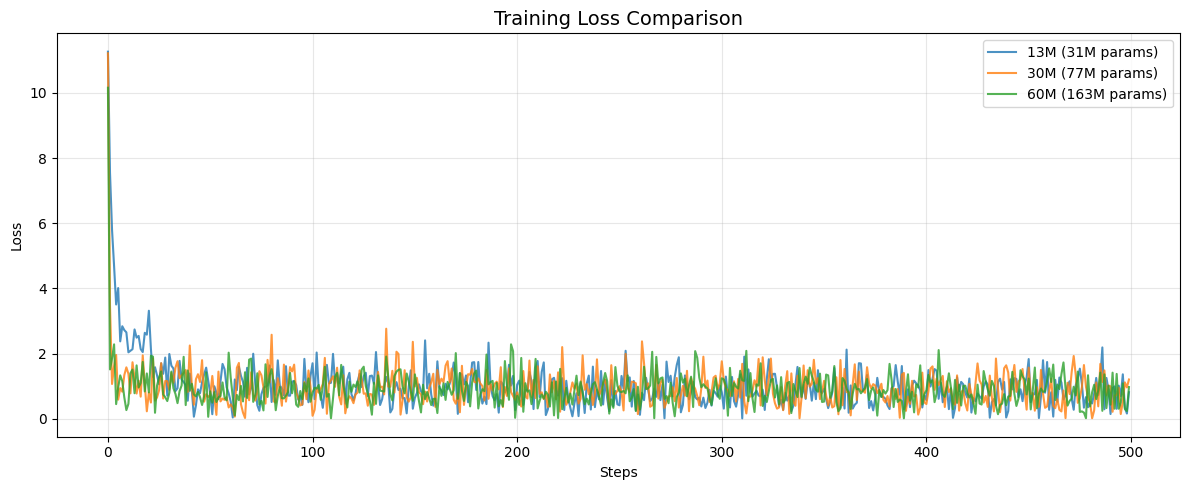

Image saved to Drive: /content/drive/MyDrive/llm_project/benchmarks/images/benchmark_loss_curves.png


In [14]:
plt.figure(figsize=(12, 5))

for size, r in results.items():
    plt.plot(r['losses'], label=f"{size} ({r['params']} params)", alpha=0.8)

plt.title('Training Loss Comparison', fontsize=14)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('benchmark_loss_curves.png', dpi=150)
plt.show()

# Save image to Drive
shutil.copy('benchmark_loss_curves.png', f'{DRIVE_DIR}/images/benchmark_loss_curves.png')
print(f'Image saved to Drive: {DRIVE_DIR}/images/benchmark_loss_curves.png')

In [15]:
print('\n' + '='*65)
print(f"{'Model':<8} {'Params':<8} {'Loss':<10} {'PPL':<12} {'Time(s)':<12} {'GPU(GB)'}")
print('='*65)
for size, r in results.items():
    print(f"{r['model_size']:<8} {r['params']:<8} {r['final_loss']:<10} "
          f"{r['perplexity']:<12} {r['training_time']:<12} {r['gpu_memory_gb']}")
print('='*65)


Model    Params   Loss       PPL          Time(s)      GPU(GB)
13M      31M      0.8448     2.33         131.5        7.9
30M      77M      0.803      2.23         275.8        9.42
60M      163M     0.8267     2.29         658.4        11.19


In [16]:
# Save all 3 model checkpoints to Drive
for size, r in results.items():
    ckpt_path = f'{DRIVE_DIR}/checkpoints/model_{size}.pt'
    torch.save({
        'model_state_dict': r['model'].state_dict(),
        'config':           MODEL_CONFIGS[size],
        'final_loss':       r['final_loss'],
        'perplexity':       r['perplexity'],
        'training_time':    r['training_time'],
    }, ckpt_path)
    print(f'{size} checkpoint saved -> {ckpt_path}')

# Save results as JSON
summary = {
    size: {k: v for k, v in r.items() if k not in ('model', 'losses')}
    for size, r in results.items()
}
json_path = f'{DRIVE_DIR}/benchmark_results.json'
with open(json_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Results JSON saved -> {json_path}')

13M checkpoint saved -> /content/drive/MyDrive/llm_project/benchmarks/checkpoints/model_13M.pt
30M checkpoint saved -> /content/drive/MyDrive/llm_project/benchmarks/checkpoints/model_30M.pt
60M checkpoint saved -> /content/drive/MyDrive/llm_project/benchmarks/checkpoints/model_60M.pt
Results JSON saved -> /content/drive/MyDrive/llm_project/benchmarks/benchmark_results.json


In [18]:
def generate_text(model, prompt, tokenizer, max_new_tokens=50, device='cuda'):
    model.eval()
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            # Trim to context window if needed
            input_ids = input_ids[:, -model.context_length:]

            output = model(input_ids)  # forward() with no targets → returns logits only
            # Defensive unpack in case model returns (logits, loss)
            logits = output[0] if isinstance(output, tuple) else output

            next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            input_ids = torch.cat([input_ids, next_token], dim=1)

    generated_ids = input_ids[0].tolist()
    return tokenizer.decode(generated_ids, skip_special_tokens=True)


# --- Run generation ---
prompt = "The history of artificial intelligence"
print(f"\nPrompt: '{prompt}'\n{'='*50}")
for size, r in results.items():
    generated = generate_text(r['model'], prompt, tokenizer, device=device)
    print(f'\n[{size}]: {generated}\n')



Prompt: 'The history of artificial intelligence'

[13M]: The history of artificial intelligence , the first of the first in the first first in the first in the first of the first . 



[30M]: The history of artificial intelligence , the song of the song of the first time , the song of the song of the song of the song of the song of the season , the song of the first time , the song of the first time , the song of the song of the


[60M]: The history of artificial intelligence , the first first first first first first first first first first first first first first first first first first first first first first time , and the first first first first first first first first first first first first first first first first first first of the first first

